# Mô hình Baseline: SARIMAX
Trong phần này, chúng ta sẽ xây dựng mô hình thống kê SARIMAX làm cơ sở (baseline).
Vì SARIMAX hoạt động tốt với dữ liệu có tính chu kỳ cố định và đơn giản, chúng ta sẽ chuyển đổi dữ liệu theo giờ (hourly) thành dữ liệu trung bình ngày (daily) để tránh mô hình bị nhiễu bởi chu kỳ phức tạp trong ngày.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

# Đọc dữ liệu đúng file đã làm sạch
df = pd.read_csv('../data/processed/pm25_training_data.csv')
df['datetime'] = pd.to_datetime(df['datetime'])

# Chọn 1 thành phố đại diện (Hà Nội - nơi có ô nhiễm rõ rệt nhất)
df_hn = df[df['city'] == 'Hà Nội'].sort_values('datetime').set_index('datetime')

# Resample về trung bình ngày (Daily)
df_hourly = df_hn.copy() # Sử dụng dữ liệu theo giờ cho đồng bộ

# Bỏ các ngày bị thiếu PM2.5 (nếu có)
df_hourly = df_hourly.dropna(subset=['pm25'])

print(f"Dữ liệu sau khi gom theo ngày còn lại: {len(df_hourly)} ngày")
display(df_hourly.head(3))

Dữ liệu sau khi gom theo ngày còn lại: 1374 ngày


,pm25,pm10,o3,no2,so2,co,eu_aqi,temp,humidity,wind_speed,...,is_weekend,day_of_year,pm25_lag_1h,pm25_lag_3h,pm25_lag_6h,pm25_lag_12h,pm25_lag_24h,pm25_roll_6h,pm25_roll_24h,pm25_roll_72h
datetime,,,,,,,,,,,,,,,,,,,,,
2022-08-05,36.029412,51.570588,76.235294,44.173529,21.841176,655.647059,68.841569,27.994118,84.107383,6.607095,...,0.0,217.0,34.643750,31.550000,26.609091,19.580000,NaN,30.583627,25.359882,25.359882
2022-08-06,28.566667,40.895833,38.875000,36.154167,14.908333,481.666667,68.091387,25.937500,91.143819,5.360842,...,1.0,218.0,29.716667,31.604167,33.554167,36.962500,36.029412,30.949306,35.579801,34.601322
2022-08-07,26.070833,37.641667,55.666667,27.531250,12.366667,387.750000,52.020837,26.345833,90.955865,7.408773,...,1.0,219.0,25.004167,23.491667,22.716667,21.691667,28.566667,24.150694,23.132465,29.214380


## Chia tập Train/Test
Chúng ta sử dụng **Time-series split** (chia theo trình tự thời gian). 
Giữ lại 80% dữ liệu ở quá khứ để huấn luyện và 20% dữ liệu ở tương lai (gần nhất) để kiểm thử. Không được phép chia ngẫu nhiên (random split) đối với chuỗi thời gian.

In [2]:
# Cắt 80% thời gian đầu làm Train, 20% thời gian sau làm Test
train_size = int(len(df_hourly) * 0.8)
train = df_hourly.iloc[:train_size]
test = df_hourly.iloc[train_size:]

print(f"Tập Train: Từ {train.index.min().date()} đến {train.index.max().date()} ({len(train)} ngày)")
print(f"Tập Test:  Từ {test.index.min().date()} đến {test.index.max().date()} ({len(test)} ngày)")

# Chọn biến mục tiêu (Target) và biến ngoại sinh (Exogenous)
target = 'pm25'
exog_cols = ['temp', 'humidity', 'wind_speed', 'pressure']

y_train, X_train = train[target], train[exog_cols]
y_test, X_test = test[target], test[exog_cols]

Tập Train: Từ 2022-08-05 đến 2025-08-07 (1099 ngày)
Tập Test:  Từ 2025-08-08 đến 2026-05-09 (275 ngày)


## Huấn luyện và Đánh giá SARIMAX
Sử dụng mô hình SARIMAX với các tham số dự đoán mùa vụ và kết hợp thêm các biến ngoại sinh.

Đang huấn luyện SARIMAX (quá trình này có thể mất vài phút)...

📊 KẾT QUẢ SARIMAX BASELINE:
   RMSE: 17.50 µg/m³
   MAE:  13.72 µg/m³


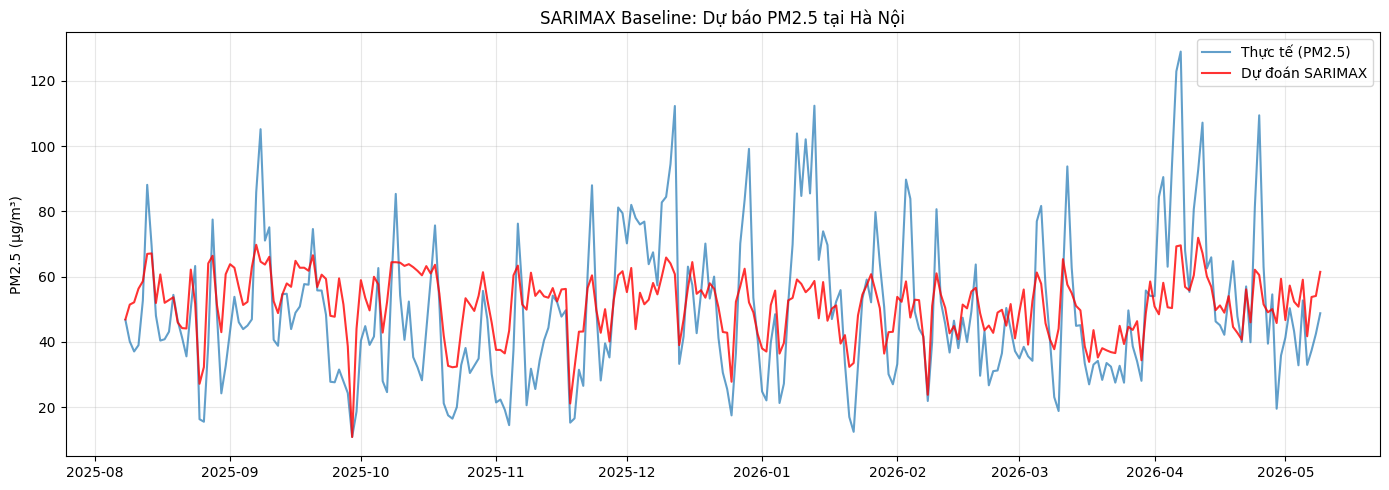

In [3]:
print("Đang huấn luyện SARIMAX (quá trình này có thể mất vài phút)...")

# Cấu hình SARIMAX(p,d,q)(P,D,Q,s)
# s=24 để mô hình hiểu chu kỳ 24 giờ trong ngày
model = SARIMAX(
    y_train,
    exog=X_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 24)
)
results = model.fit(disp=False)

# Dự đoán trên tập Test
predictions = results.predict(
    start=len(train),
    end=len(train) + len(test) - 1,
    exog=X_test
)

# Tính toán sai số
rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)

print(f"\n📊 KẾT QUẢ SARIMAX BASELINE:")
print(f"   RMSE: {rmse:.2f} µg/m³")
print(f"   MAE:  {mae:.2f} µg/m³")

# Trực quan hóa kết quả
plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test.values, label='Thực tế (PM2.5)', alpha=0.7)
plt.plot(y_test.index, predictions.values, color='red', label='Dự đoán SARIMAX', alpha=0.8)
plt.title('SARIMAX Baseline: Dự báo PM2.5 tại Hà Nội')
plt.ylabel('PM2.5 (µg/m³)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()